### **Student Information**
Name: **Samuel Montes**

Student ID: **114065429**

GitHub ID: **105062384**

Kaggle name: **samjun99**

Kaggle private scoreboard snapshot: 

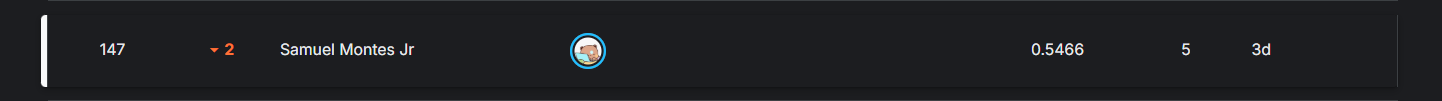

---

**`From here on starts the code section for the competition.`**

---

# 1 **Competition Code**

## 1.1 File Handling

For the first part, first thing that I did is to handle the files that will be used as the input to this data. Since the actual dataset, labels, and the identifier for the train/test set are separated in different files. My goal in this first section is to have 2 dataframes having the `type`, `post_id`, `text`, `hashtags`, `split`, `emotion`.

Since the dataset file is in .json format, I used a package from pandas to transform the json structure into a flat, dataframe like table for the merging.

In [1]:
import json
import pandas as pd
from pandas import json_normalize

with open('/kaggle/input/phase-3-dataset/final_posts.json') as f:
    data = json.load(f)

df = json_normalize(data)
df.columns = df.columns.str.replace('root._source.post.', '')
df.columns = df.columns.str.replace('root.', '')

id_df = pd.read_csv('/kaggle/input/phase-3-dataset/data_identification.csv')
id_df = id_df.rename(columns={'id': 'post_id'})

df = df.merge(id_df, on='post_id', how='left')

emotions_df = pd.read_csv('/kaggle/input/phase-3-dataset/emotion.csv')
emotions_df = emotions_df.rename(columns={'id': 'post_id'})

df = df.merge(emotions_df, on='post_id', how='left')

### 1.1.1 Split the table into Train/Test set

In [2]:
train_df = df[df['split'] == 'train'].reset_index(drop=True)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)

print(train_df.head())
print(test_df.head())
print("\n__________________________________________")
print("number of records in train dataset: ", len(train_df))
print("number of records in test dataset: ", len(test_df))

  _type   post_id                                               text hashtags  \
0  post  0x35663e  I bet there is an army of married couples who ...       []   
1  post  0xc78afe                         This could only end badly.       []   
2  post  0x90089c  My sister squeezed a lime in her milk when she...       []   
3  post  0x2ffb63                                Thank you so much❤️       []   
4  post  0x989146  Stinks because ive been in this program for a ...       []   

   split emotion  
0  train     joy  
1  train    fear  
2  train     joy  
3  train     joy  
4  train     joy  
  _type   post_id                                               text hashtags  \
0  post  0x61fc95  We got the ranch, loaded our guns and sat up t...       []   
1  post  0xaba820         and that got my head bobbing a little bit.       []   
2  post  0x66e44d                Same. Glad it's not just out store.       []   
3  post  0xc03cf5  Like always i will wait and see thanks for the...       

### 1.1.2 Plot Term Frequency

We generate a plot to check the frequency of terms in the training dataset.

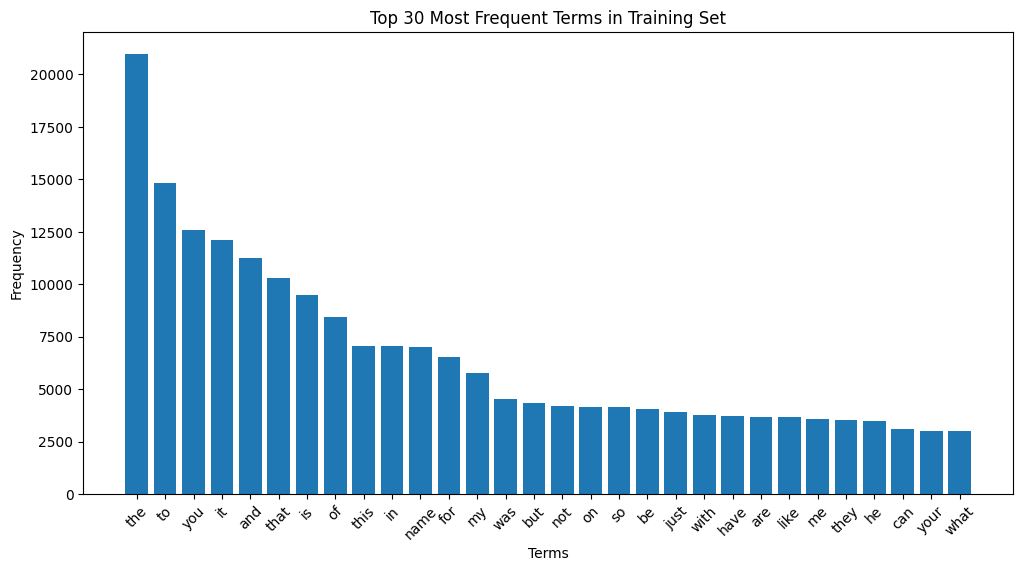

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt

count_vectorizer = CountVectorizer(
    max_features=30,
#    stop_words='english',
    lowercase=True
)

X_counts = count_vectorizer.fit_transform(train_df['text'])

term_frequencies = X_counts.sum(axis=0)
terms = count_vectorizer.get_feature_names_out()
frequencies = term_frequencies.A1

freq_df = pd.DataFrame({'term': terms, 'frequency': frequencies}).sort_values(by='frequency', ascending=False)

plt.figure(figsize=(12,6))
plt.bar(freq_df['term'], freq_df['frequency'])
plt.xticks(rotation=45)
plt.title("Top 30 Most Frequent Terms in Training Set")
plt.xlabel("Terms")
plt.ylabel("Frequency")
plt.show()

## 1.2 Import Packages

For this implementation, we will use a **Logistic Regression** model using **TF-IDF** as its input vector. The reason for using the model is due to the remaining time and having failed attempts using other models and methods prior to having a successful training.

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

## 1.3 Convert Labels to Numeric Labels

I introduced a LabelEncooder function to convert the text labels into numerical label, this way the model can understand them for training.

In [5]:
le = LabelEncoder()
train_df['label'] = le.fit_transform(train_df['emotion'])
num_labels = len(le.classes_)
print("Classes:", le.classes_)

print(train_df[['emotion', 'label']].drop_duplicates())

Classes: ['anger' 'disgust' 'fear' 'joy' 'sadness' 'surprise']
      emotion  label
0         joy      3
1        fear      2
5       anger      0
12   surprise      5
28    sadness      4
190   disgust      1


## 1.4 Split Train and Validation

In this section, the data is further split the training into validation and train. This way we will be able to perfrom evaluation after the training to see its perfromance metrics. For this setup, I used the following:

* `test_size` = 0.2   -> The original train set will be divided into **20%** validation split, **80%** training split
* `random_state` = 42  -> This ensures that the separation of data will be the same for every run
* `stratify` -> Ensures the proportion of the data is similar to the original one

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    train_df['text'], train_df['label'],
    test_size=0.2,
    random_state=42,
    stratify=train_df['label']
)

## 1.5 Feature Extraction (TF-IDF Vector)

For this lab, I will only use the `text` attribute for the training. Henct, the `hashtags` will be omitted in this setup. The reason of this procedure is due to the small amount of time remaining after having failed attempts using other methods.

Next, we will transfrom the different data splits using the **Term Frequency-Inverse Document Frequency** used similar to the previous lab, this converts it into a term frequency based vector which will then be fed into the model for training.

In [7]:
vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,4),
    lowercase=True
#    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(test_df['text'])

## 1.6 Model Training

I used a logistic regression model to train from the TF-IDF vectors we created earlier.

In [8]:
clf = LogisticRegression(max_iter=500)
clf.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=500)

## 1.7 Evaluation

After training, we evaluate the model using the validation split to see its performance metrics.

In [9]:
y_pred_val = clf.predict(X_val_tfidf)
print("Validation Accuracy:", accuracy_score(y_val, y_pred_val))
print(classification_report(y_val, y_pred_val, target_names=le.classes_))

Validation Accuracy: 0.6165170181666318
              precision    recall  f1-score   support

       anger       0.55      0.53      0.54      2139
     disgust       0.50      0.01      0.02       237
        fear       0.64      0.21      0.32       402
         joy       0.65      0.89      0.75      4759
     sadness       0.58      0.15      0.24       785
    surprise       0.53      0.28      0.37      1256

    accuracy                           0.62      9578
   macro avg       0.57      0.34      0.37      9578
weighted avg       0.60      0.62      0.57      9578



Based from the report, my model implementation has managed to get an accuracy of **0.62**. The score is actually not a good one.

## 1.8 Predict Test Set

We then predict the test set using the trained model.

In [13]:
test_df['label'] = clf.predict(X_test_tfidf)
test_df['emotion'] = le.inverse_transform(test_df['label'])

submission = test_df[['post_id', 'emotion']]
submission.to_csv('predicted_emotions.csv', index=False, header=False)

In [14]:
print(submission)

        post_id emotion
0      0x61fc95     joy
1      0xaba820     joy
2      0x66e44d     joy
3      0xc03cf5     joy
4      0x02f65a   anger
...         ...     ...
16276  0x0f273c     joy
16277  0xfc4c5d   anger
16278  0xb318a3   anger
16279  0x8f758e     joy
16280  0x3a9174     joy

[16281 rows x 2 columns]


# 2. Other Models/Training Setup used

This part discusses the different models and training setup used in an attempt to improve the perfromance. After different trials, most models used get a lower score hence removing them from the original setup, while other models seem to freeze during training.

## 2.1 Feature Extraction (TF-IDF) with English Stop Words

As you can see from the code implementation, I did not specify any stop-words for the TF-IDF vectorization. This is because including any stop words somehow got a poorer score as comared when we include them.

For this training setup part, I am going to demonstrate if we tried to train the model with the **english stop-words** enabled.

In [15]:
vectorizer_2 = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,4),
    lowercase=True,
    stop_words='english'
)

X_train_tfidf = vectorizer_2.fit_transform(X_train)
X_val_tfidf = vectorizer_2.transform(X_val)
X_test_tfidf = vectorizer_2.transform(test_df['text'])

clf = LogisticRegression(max_iter=500)
clf.fit(X_train_tfidf, y_train)

y_pred_val = clf.predict(X_val_tfidf)
print("Validation Accuracy:", accuracy_score(y_val, y_pred_val))
print(classification_report(y_val, y_pred_val, target_names=le.classes_))

Validation Accuracy: 0.6106702860722489
              precision    recall  f1-score   support

       anger       0.54      0.54      0.54      2139
     disgust       0.58      0.03      0.06       237
        fear       0.59      0.22      0.32       402
         joy       0.65      0.88      0.75      4759
     sadness       0.56      0.21      0.30       785
    surprise       0.45      0.20      0.28      1256

    accuracy                           0.61      9578
   macro avg       0.56      0.35      0.37      9578
weighted avg       0.59      0.61      0.57      9578



As you can see, we got a accuracy of **0.61** which is 0.01 lower than the one implemented.

## 2.2 Using Lower N-grams

We will also demonstrate another setup this time using a lower n-gram.

In [19]:
vectorizer_3 = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    lowercase=True,
    stop_words='english'
)

X_train_tfidf = vectorizer_3.fit_transform(X_train)
X_val_tfidf = vectorizer_3.transform(X_val)
X_test_tfidf = vectorizer_3.transform(test_df['text'])

clf = LogisticRegression(max_iter=500)
clf.fit(X_train_tfidf, y_train)

y_pred_val = clf.predict(X_val_tfidf)
print("Validation Accuracy:", accuracy_score(y_val, y_pred_val))
print(classification_report(y_val, y_pred_val, target_names=le.classes_))

Validation Accuracy: 0.612549592816872
              precision    recall  f1-score   support

       anger       0.54      0.54      0.54      2139
     disgust       0.56      0.04      0.07       237
        fear       0.60      0.22      0.32       402
         joy       0.65      0.88      0.75      4759
     sadness       0.57      0.21      0.31       785
    surprise       0.46      0.20      0.28      1256

    accuracy                           0.61      9578
   macro avg       0.56      0.35      0.38      9578
weighted avg       0.59      0.61      0.57      9578



Based on the accuracy score, this one did not change that much as compared to when we enabled the stop-words.

## 2.3 Other Models Used

Prior to the code implementation in Section 1, I used other methods and models for the training however, some of them got a lower accuracy score while others seemed to freeze, training in an endless loop.

Here are all of the models that I attempted to use:

1. **Multinomial Naive-Bayes Classifier**
2. **Decision Trees**
3. **BERT Base**
4. **DistilledBERT**

## 2.4 Insights

From this lab, I can say that implementing a machine learning model is not a one solution fits all, some of them work only for specific tasks while other models are state-of-the-art that performs the best but are compute-resource heavy which takes too long to run. Some datasets are even simple enough that a simple model can even train with decent results. Most importantly, I learned a lot on how feature-extraction, pre-processing, etc. is essential in the entire process leveraging on improving the performance and saves on costs.

Ultimately, I gained a lot in understanding from this lab which I really appreciate and I do hope to use them outside this class.